In [41]:
import os
import glob
import json
import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt

from astropy.cosmology import Planck18 as cosmo

from corner import corner

from astropy import constants as c

import syncfit

from otter import Otter

In [48]:
otterpath = os.path.join(os.getcwd(), "private_otter_data")
overwrite = False

radio_phot = pd.read_csv("ecle-photometry.csv")
meta = pd.read_csv("ecle-metadata.csv")

if overwrite:

    wise_phot = pd.read_csv("data/wise-photometry.csv", index_col=0)
    
    wise_phot["date"] = wise_phot["date_mjd"]
    wise_phot["date_format"] = "mjd"
    wise_phot["filter_eff_units"] = wise_phot["filter_eff_unit"]
    
    if os.path.exists(otterpath):
        for file in glob.glob(os.path.join(otterpath, "*")):
            os.remove(file)
        os.rmdir(otterpath)


    private_data = Otter.from_csvs("ecle-metadata.csv", photfile="all-photometry.csv", local_outpath=otterpath)
else:
    private_data = Otter(
        url="http://localhost:8529",
        username="user-guest",
        password="",
        datadir=otterpath,
        gen_summary=True
    )
    
radio = private_data.get_phot(
    names=meta.name.to_list(), 
    obs_type="radio", 
    query_private=True, 
    return_type="pandas",
    flux_unit="mJy",
    freq_unit="GHz"
)

/home/nfranz/astro-otter/otter/src/otter/io/transient.py:874: UserWarning: Names have the same score! Just using the existing default_name
  warnings.warn(
/home/nfranz/astro-otter/otter/src/otter/io/transient.py:632: UserWarning: Unable to apply the source mapping because 'private'
  warnings.warn(f"Unable to apply the source mapping because {exc}")
/home/nfranz/astro-otter/otter/src/otter/io/transient.py:632: UserWarning: Unable to apply the source mapping because 'private'
  warnings.warn(f"Unable to apply the source mapping because {exc}")
/home/nfranz/astro-otter/otter/src/otter/io/transient.py:632: UserWarning: Unable to apply the source mapping because Cannot set a DataFrame with multiple columns to the single column human_readable_refs
  warnings.warn(f"Unable to apply the source mapping because {exc}")
/home/nfranz/astro-otter/otter/src/otter/io/transient.py:632: UserWarning: Unable to apply the source mapping because 'private'
  warnings.warn(f"Unable to apply the source mapp

In [49]:
def get_bounds(chain, ndim=3):
    
    medians, upper, lower = [], [], []
    for i in range(ndim):
        mcmc = np.percentile(chain[:, i], [16, 50, 84])
        q = np.diff(mcmc)
        vals = [mcmc[1],(q[0]+q[1])/2]

        medians.append(mcmc[1])
        upper.append(q[1])
        lower.append(q[0])

    return medians, upper, lower

def choose_sideband_fullband(df):

    # need same time and same band name
    result = []
    for (t, band), grp in df.groupby(["converted_date", "filter_name"]):

        if len(grp) < 3:
            # this means that it is either full or side band, not both
            for _,row in grp.iterrows():
                result.append(row)
            continue
        
        # now of these we need to choose side band if both are not upperlimits
        # and full band if either (or both) is an upperlimit

        # sorting by the converted_frequency will tell us if it is a sideband or full band
        grp = grp.sort_values("converted_freq").reset_index()

        sideband_low = grp.iloc[0]
        sideband_high = grp.iloc[-1]
        fullband = grp.iloc[1] # assume that each is only three long

        if sideband_low.upperlimit or sideband_high.upperlimit:
            # then append the fullband
            result.append(fullband)
        else:
            result.append(sideband_low)
            result.append(sideband_high)

    res = pd.DataFrame(result).reset_index()
    return res

def make_sed(tde_name, ax=None, filter_sidebands=True):
    classes = private_data.query(names=tde_name, query_private=True)[0]['classification']
    for c in classes:
        if c['object_class'] in {'AGN', 'TDE'}:
            break
    ecle_class = c['object_class']

    df = radio[radio.name == tde_name]
    if filter_sidebands:
        df = choose_sideband_fullband(df)

    
    if ax is not None:
        for label, grp in df.groupby('converted_date'):

            ax.errorbar(
                grp.converted_freq, 
                grp.converted_flux,
                fmt='o',
                markersize=3,
                yerr=grp.converted_flux_err,
                label=f'{label:.2f} MJD',
                uplims=grp.upperlimit
            )

            # next(ax._get_lines.prop_cycler)['color']


        ax.set_ylabel('Flux [Jy]')
        ax.set_xlabel('Frequency [GHz]')
        ax.set_yscale('log')

        at = AnchoredText(f'{tde_name} ({ecle_class})', 'center right', frameon=False)
        ax.add_artist(at)

        ax.legend(fontsize=12)
    
    return df

In [63]:
labels = ["p", 'log_F_nu', 'log_nu_a']

param_uplims = dict(
    name = ['SDSSJ1241', 'SDSSJ1241', 'SDSSJ0938', 'SDSSJ0938', 'SDSSJ0748', 'SDSSJ0748'],
    mjd_key = ['57629.5', '57959.0', '57459.0', '57912.0', '57458.0', '57914.0'],
    p_lim = [False, False, False, False, False, False], # these would be upperlimits
    p_lim_type = "upper",
    log_F_nu_lim = [True, False, True, True, True, True], # these are lower limits
    log_F_nu_lim_type = "lower",
    log_nu_a_lim = [True, False, True, True, True, True], # these are upperlimits on nu_a
    log_nu_a_lim_type = "upper"
)

best_fit_params = dict(
    name = [],
    mjd_key = [],
    p = [],
    p_up = [],
    p_lo = [],
    p_chain = [],
    log_F_nu = [],
    log_F_nu_up = [],
    log_F_nu_lo = [],
    log_F_nu_chain = [],
    log_nu_a = [],
    log_nu_a_up = [],
    log_nu_a_lo = [],
    log_nu_a_chain = [],
)

sed_data = dict(
    mjd_key = [],
    mjd = [],
    name = [],
    flux = [],
    flux_err = [],
    freq = []
)

name_map = {
    "SDSSJ1241" : "SDSS_J1241",
    "SDSSJ0938" : "SDSS_J0938",
    "SDSSJ0748" : "SDSS_J0748"
}

date_range_map = {
    "SDSSJ1241" : [
        (57918, 58000), # this is the best sampled SED so it needs to go first so we can compute p

        # (50506, 50507),
        (57459, 57800), 
        # (58580, 58590),
        # (58753, 58755), #     | I have all of these commented out because they are from a separate program
        # (59000, 59100), # --> | We can use them at some point but I don't really feel like that
        # (59400, 59600)  #     | are adding much to the analysis
    ],
    
    "SDSSJ0938" : [
        (57911, 57913),
        (57458, 57460)
    ],

    "SDSSJ0748" : [
        (57913, 57915),
        (57457, 57459)
    ]
}

for jfile in glob.glob(os.path.join(os.getcwd(), "*chains.json")):

    with open(jfile, "r") as j:
        chain_dict = json.load(j)
    print(jfile)
    tname = jfile.split('-')[1].split('/')[1]

    print(tname)

    for k, chain in chain_dict.items():
        medians, uplims, lowlims = get_bounds(np.array(chain))
        print(f"\tMJD = {k}")
        for median, uplim, lowlim, lab, chain_by_key in zip(medians, uplims, lowlims, labels, np.array(chain).T):
            print(f"\t\t${lab} = {median:.2f}^+{uplim:.2f}_-{lowlim:.2f}$")

            best_fit_params[lab].append(median)
            best_fit_params[f"{lab}_up"].append(uplim)
            best_fit_params[f"{lab}_lo"].append(lowlim)
            best_fit_params[f"{lab}_chain"].append(chain_by_key)
        best_fit_params["mjd_key"].append(k)
        best_fit_params["name"].append(tname)
        
    
    data = make_sed(name_map[tname])
    
    for date_range in date_range_map[tname]:
        
        this_data = data[(data.converted_date > date_range[0]) * (data.converted_date < date_range[1])]
        
        print(this_data.converted_date.unique())
        sed_data["mjd_key"].append(sum(date_range)/2)
        sed_data["mjd"].append(this_data.converted_date.values[0])
        sed_data["name"].append(tname)
        sed_data["flux"].append(this_data.converted_flux.values)
        sed_data["flux_err"].append(this_data.converted_flux_err.values)
        sed_data["freq"].append(this_data.converted_freq.values)

res = pd.DataFrame(best_fit_params).merge(pd.DataFrame(param_uplims), on=["name", "mjd_key"])
res.mjd_key = res.mjd_key.astype(float)
res = res.merge(pd.DataFrame(sed_data), on=["name", "mjd_key"])

res

/home/nfranz/radio-ecle/SDSSJ1241-radio-chains.json
SDSSJ1241
	MJD = 57959.0
		$p = 3.92^+0.06_-0.08$
		$log_F_nu = 1.18^+0.02_-0.02$
		$log_nu_a = 8.99^+0.02_-0.02$
	MJD = 57629.5
		$p = 3.88^+0.09_-0.08$
		$log_F_nu = 1.08^+0.27_-0.11$
		$log_nu_a = 9.10^+0.10_-0.21$
[57918.05305]
[57459.16642]
/home/nfranz/radio-ecle/SDSSJ0938-radio-chains.json
SDSSJ0938
	MJD = 57912.0
		$p = 3.08^+0.12_-0.08$
		$log_F_nu = 1.30^+0.46_-0.29$
		$log_nu_a = 8.36^+0.36_-0.47$
	MJD = 57459.0
		$p = 3.11^+0.09_-0.10$
		$log_F_nu = 1.31^+0.47_-0.47$
		$log_nu_a = 8.49^+0.46_-0.45$
[57911.79545]
[57459.04178]
/home/nfranz/radio-ecle/SDSSJ0748-radio-chains.json
SDSSJ0748
	MJD = 57914.0
		$p = 2.59^+0.34_-0.31$
		$log_F_nu = 0.41^+0.84_-0.71$
		$log_nu_a = 7.65^+1.03_-1.05$
	MJD = 57458.0
		$p = 2.62^+0.13_-0.13$
		$log_F_nu = 0.65^+0.89_-0.89$
		$log_nu_a = 7.80^+1.11_-1.11$
[57914.71674]
[57458.9162]


/home/nfranz/astro-otter/otter/src/otter/io/transient.py:874: UserWarning: Names have the same score! Just using the existing default_name
  warnings.warn(


,name,mjd_key,p,p_up,p_lo,p_chain,log_F_nu,log_F_nu_up,log_F_nu_lo,log_F_nu_chain,...,p_lim,p_lim_type,log_F_nu_lim,log_F_nu_lim_type,log_nu_a_lim,log_nu_a_lim_type,mjd,flux,flux_err,freq
0,SDSSJ1241,57959.0,3.920903,0.055025,0.083077,"[3.0049657740184856, 3.0010281263657257, 3.000...",1.175365,0.016536,0.018017,"[0.9909119054822503, 0.9941782983059854, 1.001...",...,False,upper,False,lower,False,upper,57918.05305,"[1.2176, 0.8375, 4.3203000000000005, 4.1259, 2...","[0.040400000000000005, 0.031100000000000003, 0...","[4.999, 7.099, 1.2999999999999998, 1.775, 2.62..."
1,SDSSJ1241,57629.5,3.877922,0.085578,0.076951,"[3.9340857138140164, 3.9190376794936714, 3.914...",1.083294,0.265146,0.111470,"[1.0086813402090888, 1.0041549375264336, 1.001...",...,False,upper,True,lower,True,upper,57459.16642,"[1.502, 0.96]","[0.0201, 0.0163]","[4.999, 7.099]"
2,SDSSJ0938,57912.0,3.081853,0.122519,0.081857,"[3.0010275068929424, 2.990421810647745, 3.0069...",1.297415,0.464983,0.293400,"[0.9922377944666052, 1.0054323015722957, 0.992...",...,False,upper,True,lower,True,upper,57911.79545,"[0.9706, 0.5897000000000001, 3.4218, 2.5266, 1...","[0.058499999999999996, 0.0379, 0.1963000000000...","[4.999, 7.099, 1.255, 1.644, 2.599, 3.39900000..."
3,SDSSJ0938,57459.0,3.112252,0.092424,0.095087,"[3.0833806643032777, 3.072689053518213, 3.0783...",1.309558,0.471109,0.473921,"[0.9954455437367415, 1.002645844777471, 1.0036...",...,False,upper,True,lower,True,upper,57459.04178,"[1.0924, 0.7453]","[0.0283, 0.0255]","[4.999, 7.099]"
4,SDSSJ0748,57914.0,2.590281,0.340513,0.306848,"[2.9971661030039187, 2.9927683159084366, 2.993...",0.409951,0.844192,0.713918,"[1.0032325646876552, 1.0047088985977595, 1.007...",...,False,upper,True,lower,True,upper,57914.71674,"[0.0716, 0.0468, 0.19340000000000002, 0.1977, ...","[0.020600000000000004, 0.015700000000000002, 0...","[4.999, 7.099, 1.255, 1.644, 2.599, 3.39900000..."
5,SDSSJ0748,57458.0,2.615977,0.128486,0.125098,"[2.5893171848730145, 2.5979619176830204, 2.580...",0.645441,0.887906,0.891467,"[0.9920297540159176, 1.0077216786031211, 0.993...",...,False,upper,True,lower,True,upper,57458.91620,"[0.13030000000000003, 0.09540000000000001]","[0.013500000000000002, 0.0092]","[4.999, 7.099]"


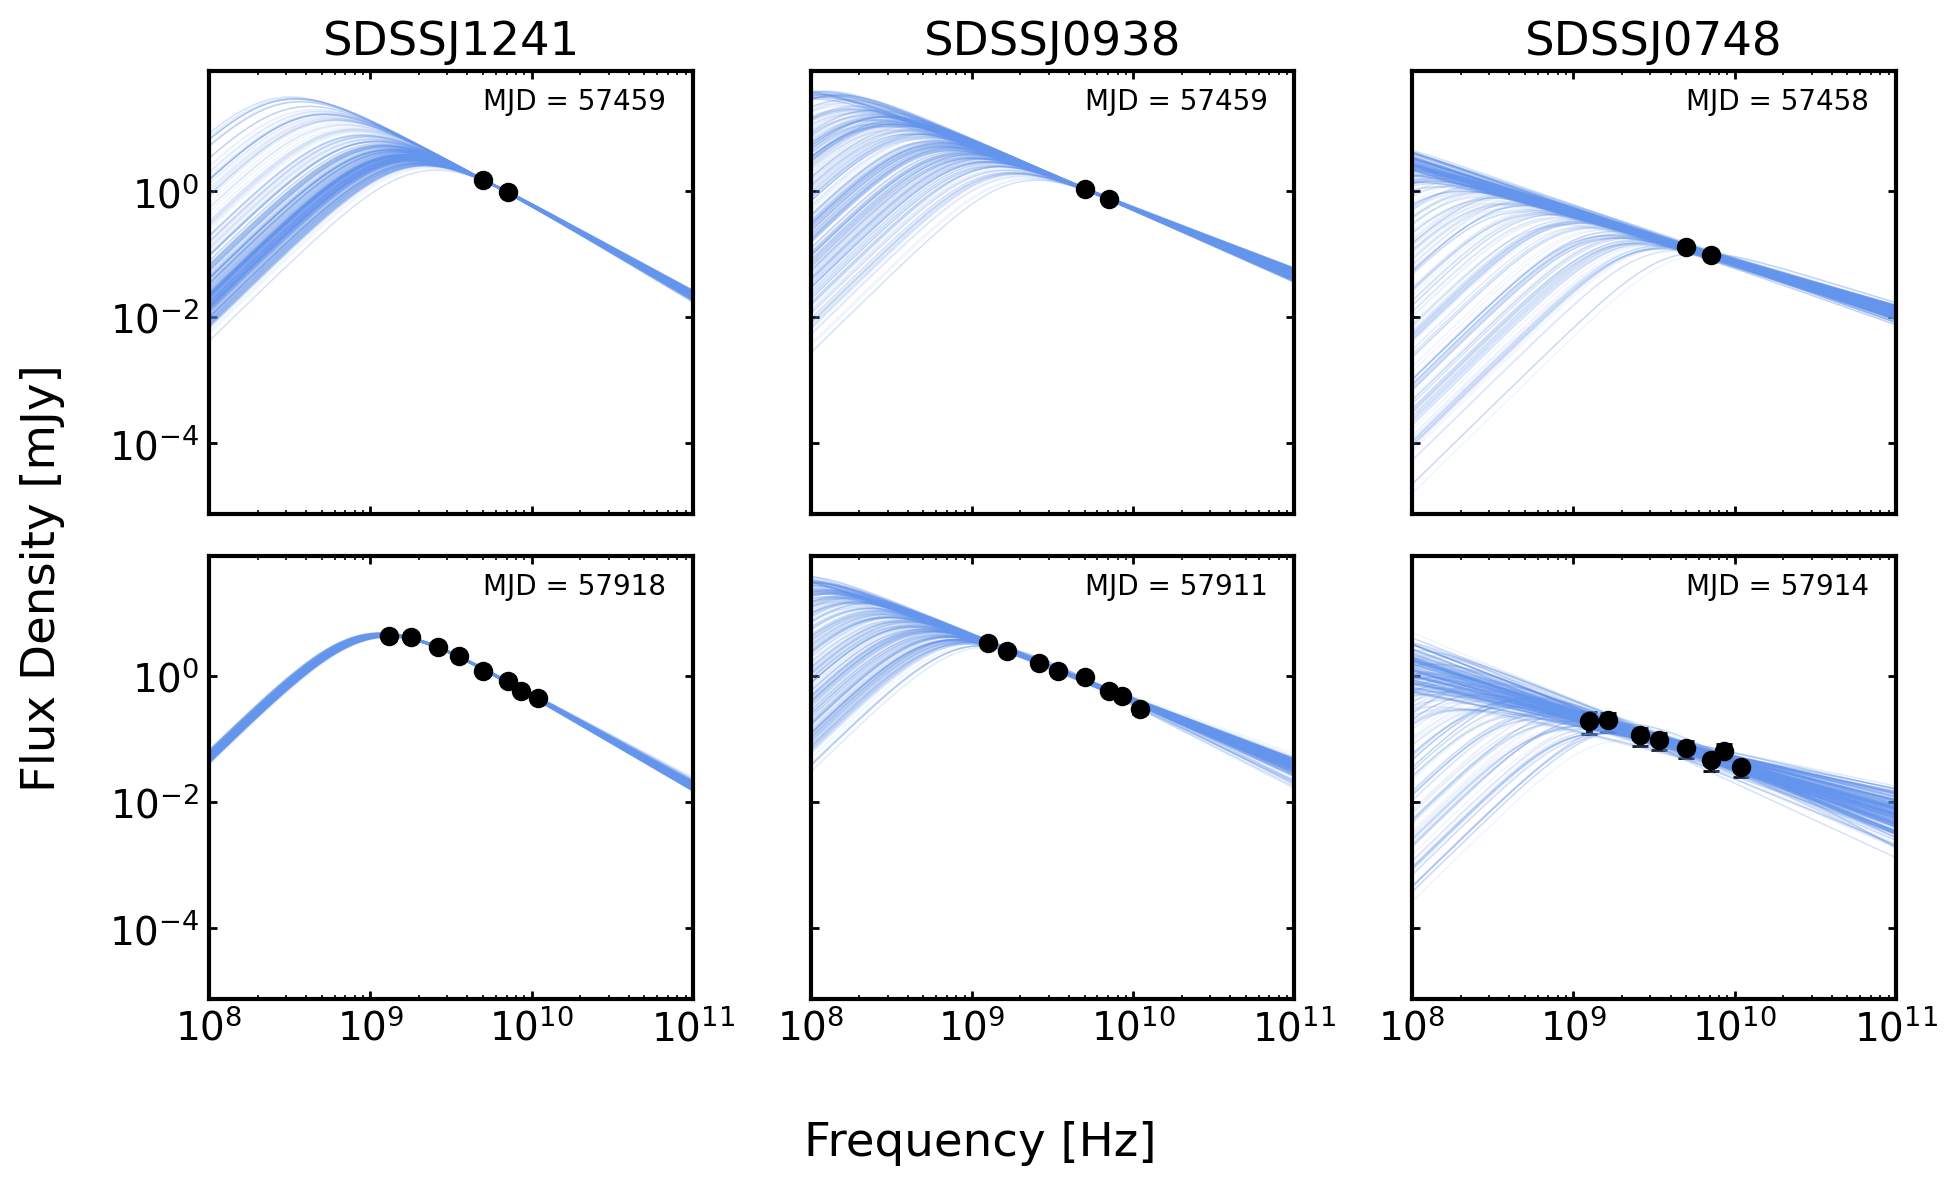

In [74]:
# plot the results over the SEDs
fig, axs = plt.subplots(2,3,figsize=(10,6), sharey=True, sharex=True, tight_layout=True)
nkeep = 500

ax_map = dict(
    name = res.name.to_list(),
    mjd = res.mjd.to_list(),
    ax = [
        axs[1,0],
        axs[0,0],
        axs[1,1],
        axs[0,1],
        axs[1,2],
        axs[0,2]
    ]
)

plot_res = res.merge(pd.DataFrame(ax_map), on=["name", "mjd"])

model = syncfit.models.B5()

for ii,row in plot_res.iterrows():
    
    ax = row.ax
    
    if ii%2:
        ax.set_title(row["name"])
    
    # plot the data
    ax.errorbar(
        row.freq*1e9,
        row.flux,
        yerr = row.flux_err,
        marker = "o",
        color = "k",
        linestyle = "none",
        capsize = 3
    )
    
    # plot the fit results
    flat_samples = np.array([
        row.p_chain,
        row.log_F_nu_chain,
        row.log_nu_a_chain
    ]).T
    toplot = flat_samples[-nkeep:]
    nu_plot = np.logspace(8,11,100)
    for val in toplot:
        packed_theta = model.pack_theta(val)
        model_res = model.SED(nu_plot, **packed_theta)

        ax.plot(nu_plot, model_res, '-', color='cornflowerblue', lw = 0.5, alpha = 0.1)
        
    ax.text(5e9, 2e1, f"MJD = {int(row.mjd)}", fontsize=10)

    ax.set_yscale("log")
    ax.set_xscale("log")
    
ax.set_xlim(1e8, 1e11)
        
fig.supylabel("Flux Density [mJy]")
fig.supxlabel("Frequency [Hz]")

fig.savefig("ecle-radio-fits.png")